In [4]:
%pip install scikit-learn

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (15, 5)

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
from sklearn.datasets import load_iris
import os

# Define the path for the CSV file in sample_data
sample_data_path = '/Datasets'
csv_filename = 'IRIS_DATA.csv'
full_csv_path = os.path.join(sample_data_path, csv_filename)

# Ensure the sample_data directory exists (it usually does in Colab)
if not os.path.exists(sample_data_path):
    os.makedirs(sample_data_path)

# Load the Iris dataset from sklearn
iris = load_iris()
df_iris = pd.DataFrame(data=iris.data, columns=iris.feature_names)
# Add target to the DataFrame, converting numeric target to names for better representation in CSV
df_iris['target'] = iris.target_names[iris.target]

# Save to iris_data.csv in the sample_data folder
df_iris.to_csv(full_csv_path, index=False)
print(f"Created '{csv_filename}' in '{sample_data_path}' successfully.")

Created 'IRIS_DATA.csv' in '/Datasets' successfully.


Now that `iris_data.csv` is available in `/content/sample_data`, I will modify the `load_and_prepare_data` function to load from this file.

In [6]:
def load_and_prepare_data():
    """
    Load the Iris dataset from CSV and prepare it for regression analysis.

    Returns:
        X: Feature matrix (sepal length, sepal width, petal length)
        y: Target variable (petal width)
        feature_names: Names of the features
    """
    print("="*80)
    print("LOADING IRIS DATASET FROM CSV IN SAMPLE_DATA")
    print("="*80)

    # Load iris dataset from CSV in sample_data folder
    csv_path = '/content/sample_data/iris_data.csv'
    df = pd.read_csv(csv_path)

    # Original feature names from sklearn.datasets.load_iris
    feature_columns = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)']
    # The target in the original problem was 'petal width (cm)'.
    # If the CSV has 'petal width (cm)' as a column, we use that.
    # If not, and 'target' is species, we need a different approach.
    # Assuming for now 'petal width (cm)' was implicit in the original sklearn example.
    # Let's align with the previous code's intent where 'y' was the 4th column (petal width).
    # The CSV I just generated has 'petal width (cm)' as the 4th feature, and 'target' as species.
    # I will modify the previous assumption to use the actual 4th feature as 'y'.
    target_column = 'petal width (cm)' # This assumes 'petal width (cm)' is available as a feature

    # Select first three features as predictors (sepal length, sepal width, petal length)
    X = df[feature_columns].values

    # Select fourth feature as target (Petal width)
    # The CSV created above has 'petal width (cm)' as one of the feature_names
    # So, we should select it from the df if it exists directly.
    if 'petal width (cm)' in df.columns:
        y = df['petal width (cm)'].values
    else:
        # Fallback if 'petal width (cm)' isn't a direct column, which it should be now.
        # This part might need adjustment based on exact CSV content, but based on prior context it should be fine.
        # For now, let's assume 'petal width (cm)' column is directly available.
        raise KeyError("Column 'petal width (cm)' not found in the CSV. Please ensure the CSV has this column or adjust the target selection.")

    feature_names = feature_columns

    print(f"Dataset shape: {df.shape}")
    print(f"Features (X): {feature_names}")
    print(f"Target (y): {target_column}")
    print(f"Number of samples: {len(X)}")
    print()

    return X, y, feature_names

## Section 1: Data Loading and Preprocessing

In [7]:
def load_and_prepare_data():
    """
    Load the Iris dataset and prepare it for regression analysis.

    Returns:
        X: Feature matrix (sepal length, sepal width, petal length)
        y: Target variable (petal width)
        feature_names: Names of the features
    """
    print("="*80)
    print("LOADING IRIS DATASET")
    print("="*80)

    # Load iris dataset
    iris = load_iris()

    # Create DataFrame for easier manipulation
    df = pd.DataFrame(iris.data, columns=iris.feature_names)

    # Select first three features as predictors
    X = df.iloc[:, :3].values  # Sepal length, Sepal width, Petal length

    # Select fourth feature as target (Petal width)
    y = df.iloc[:, 3].values

    feature_names = iris.feature_names[:3]

    print(f"Dataset shape: {df.shape}")
    print(f"Features (X): {feature_names}")
    print(f"Target (y): {iris.feature_names[3]}")
    print(f"Number of samples: {len(X)}")
    print()

    return X, y, feature_names

## Section 2: Helper Functions for Regression Metrics

In [8]:
def calculate_r2_score(y_true, y_pred):
    """
    Calculate R² (coefficient of determination) score.

    R² = 1 - (SS_res / SS_tot)
    where:
        SS_res = Σ(y_true - y_pred)²  (Residual Sum of Squares)
        SS_tot = Σ(y_true - y_mean)²  (Total Sum of Squares)

    Args:
        y_true: Actual values
        y_pred: Predicted values

    Returns:
        R² score (float between 0 and 1, higher is better)
    """
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    return r2

def calculate_adjusted_r2(y_true, y_pred, n_features):
    """
    Calculate Adjusted R² score.

    Adjusted R² = 1 - [(1 - R²) * (n - 1) / (n - p - 1)]
    where:
        n = number of samples
        p = number of features (excluding bias)

    Adjusted R² penalizes the addition of features that don't improve the model.

    Args:
        y_true: Actual values
        y_pred: Predicted values
        n_features: Number of features used (excluding bias term)

    Returns:
        Adjusted R² score
    """
    n = len(y_true)
    r2 = calculate_r2_score(y_true, y_pred)
    adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - n_features - 1))
    return adjusted_r2

def mean_squared_error(y_true, y_pred):
    """Calculate Mean Squared Error."""
    return np.mean((y_true - y_pred) ** 2)

## Section 3: Ordinary Least Squares (OLS) Implementation

The OLS solution is given by: **θ = (X^T * X)^(-1) * X^T * y**

This is the closed-form solution that minimizes the sum of squared residuals.

In [9]:
def ols_regression(X, y):
    """
    Implement Ordinary Least Squares regression using matrix operations.

    The OLS solution is given by:
        θ = (X^T * X)^(-1) * X^T * y

    where:
        θ = parameter vector (weights)
        X = design matrix (with bias term)
        y = target vector

    This is the closed-form solution that minimizes the sum of squared residuals.

    Args:
        X: Feature matrix with bias term (n_samples x n_features)
        y: Target vector (n_samples,)

    Returns:
        theta: Optimal parameters
    """
    # Calculate (X^T * X)
    XtX = np.dot(X.T, X)

    # Calculate (X^T * X)^(-1)
    XtX_inv = np.linalg.inv(XtX)

    # Calculate (X^T * X)^(-1) * X^T
    XtX_inv_Xt = np.dot(XtX_inv, X.T)

    # Calculate final theta: (X^T * X)^(-1) * X^T * y
    theta = np.dot(XtX_inv_Xt, y)

    return theta

## Section 4: Batch Gradient Descent Implementation

**Algorithm:**
1. Initialize θ randomly
2. For each iteration:
   - Compute predictions: ŷ = X * θ
   - Compute gradient: ∇J = (1/m) * X^T * (ŷ - y)
   - Update parameters: θ = θ - α * ∇J
3. Repeat until convergence or max iterations

In [10]:
def batch_gradient_descent(X, y, learning_rate=0.01, n_iterations=1000, tolerance=1e-6):
    """
    Implement Batch Gradient Descent for linear regression.

    Algorithm:
        1. Initialize θ randomly
        2. For each iteration:
           a. Compute predictions: ŷ = X * θ
           b. Compute gradient: ∇J = (1/m) * X^T * (ŷ - y)
           c. Update parameters: θ = θ - α * ∇J
        3. Repeat until convergence or max iterations

    Args:
        X: Feature matrix with bias term
        y: Target vector
        learning_rate: Step size for parameter updates (α)
        n_iterations: Maximum number of iterations
        tolerance: Convergence threshold for cost change

    Returns:
        theta: Optimized parameters
        cost_history: List of cost values at each iteration
    """
    m, n = X.shape  # m = number of samples, n = number of features

    # Initialize theta with small random values
    theta = np.random.randn(n) * 0.01

    cost_history = []

    for iteration in range(n_iterations):
        # Forward pass: compute predictions
        y_pred = np.dot(X, theta)

        # Compute cost (Mean Squared Error)
        cost = np.mean((y_pred - y) ** 2)
        cost_history.append(cost)

        # Compute gradient: (1/m) * X^T * (predictions - actual)
        gradient = (1/m) * np.dot(X.T, (y_pred - y))

        # Update parameters using gradient descent rule
        theta = theta - learning_rate * gradient

        # Check for convergence
        if iteration > 0 and abs(cost_history[-2] - cost_history[-1]) < tolerance:
            print(f"  Converged at iteration {iteration + 1}")
            break

    return theta, cost_history

## Section 5: Visualization Functions

In [11]:
def plot_results(y_test, y_pred_ols, y_pred_gd, cost_history, n_features,
                 method_name, r2_ols, r2_gd):
    """
    Create comprehensive visualizations for regression results.

    Args:
        y_test: Actual test values
        y_pred_ols: OLS predictions
        y_pred_gd: Gradient descent predictions
        cost_history: Cost values during training
        n_features: Number of features used
        method_name: Description of the experiment
        r2_ols: R² score for OLS
        r2_gd: R² score for Gradient Descent
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Regression Analysis: {method_name}',
                 fontsize=16, fontweight='bold', y=1.02)

    # Plot 1: Actual vs Predicted (OLS)
    ax1 = axes[0]
    ax1.scatter(y_test, y_pred_ols, alpha=0.6, s=100, edgecolors='black',
                linewidth=1, label='Predictions')

    # Perfect prediction line
    min_val = min(y_test.min(), y_pred_ols.min())
    max_val = max(y_test.max(), y_pred_ols.max())
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--',
             linewidth=2, label='Perfect Prediction')

    ax1.set_xlabel('Actual Petal Width', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Predicted Petal Width (OLS)', fontsize=12, fontweight='bold')
    ax1.set_title(f'OLS Method\nR² = {r2_ols:.4f}', fontsize=13, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=10)
    ax1.grid(True, alpha=0.3)

    # Plot 2: Actual vs Predicted (Gradient Descent)
    ax2 = axes[1]
    ax2.scatter(y_test, y_pred_gd, alpha=0.6, s=100, edgecolors='black',
                linewidth=1, color='green', label='Predictions')

    ax2.plot([min_val, max_val], [min_val, max_val], 'r--',
             linewidth=2, label='Perfect Prediction')

    ax2.set_xlabel('Actual Petal Width', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Predicted Petal Width (GD)', fontsize=12, fontweight='bold')
    ax2.set_title(f'Gradient Descent Method\nR² = {r2_gd:.4f}',
                  fontsize=13, fontweight='bold')
    ax2.legend(loc='upper left', fontsize=10)
    ax2.grid(True, alpha=0.3)

    # Plot 3: Cost Function Convergence
    ax3 = axes[2]
    iterations = range(1, len(cost_history) + 1)
    ax3.plot(iterations, cost_history, linewidth=2, color='purple')
    ax3.set_xlabel('Iteration', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Cost (MSE)', fontsize=12, fontweight='bold')
    ax3.set_title('Gradient Descent Convergence', fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3)

    # Add convergence annotations
    initial_cost = cost_history[0]
    final_cost = cost_history[-1]
    ax3.annotate(f'Initial: {initial_cost:.4f}',
                xy=(1, initial_cost),
                xytext=(len(cost_history)*0.3, initial_cost),
                fontsize=9,
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
    ax3.annotate(f'Final: {final_cost:.4f}',
                xy=(len(cost_history), final_cost),
                xytext=(len(cost_history)*0.5, final_cost + (initial_cost-final_cost)*0.2),
                fontsize=9,
                arrowprops=dict(arrowstyle='->', color='green', lw=1.5))

    plt.tight_layout()
    plt.show()
    print()

def plot_residuals(y_test, y_pred_ols, y_pred_gd, method_name):
    """
    Plot residual analysis for both methods.

    Residuals = Actual - Predicted
    Good models should have residuals randomly distributed around zero.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Residual Analysis: {method_name}',
                 fontsize=16, fontweight='bold', y=1.02)

    # Calculate residuals
    residuals_ols = y_test - y_pred_ols
    residuals_gd = y_test - y_pred_gd

    # Plot 1: OLS Residuals
    ax1 = axes[0]
    ax1.scatter(y_pred_ols, residuals_ols, alpha=0.6, s=100,
                edgecolors='black', linewidth=1)
    ax1.axhline(y=0, color='r', linestyle='--', linewidth=2, label='Zero Line')
    ax1.set_xlabel('Predicted Values (OLS)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Residuals', fontsize=12, fontweight='bold')
    ax1.set_title('OLS Residual Plot', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # Plot 2: Gradient Descent Residuals
    ax2 = axes[1]
    ax2.scatter(y_pred_gd, residuals_gd, alpha=0.6, s=100,
                edgecolors='black', linewidth=1, color='green')
    ax2.axhline(y=0, color='r', linestyle='--', linewidth=2, label='Zero Line')
    ax2.set_xlabel('Predicted Values (GD)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Residuals', fontsize=12, fontweight='bold')
    ax2.set_title('Gradient Descent Residual Plot', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    print()

def plot_feature_comparison(X_test, y_test, y_pred, feature_names, n_features,
                            method_name):
    """
    Plot predictions vs individual features.

    This helps visualize the relationship between each feature and the target.
    """
    if n_features == 1:
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        axes = [ax]
    else:
        fig, axes = plt.subplots(1, n_features, figsize=(6*n_features, 5))

    fig.suptitle(f'Feature vs Target: {method_name}',
                 fontsize=16, fontweight='bold', y=1.02)

    for i in range(n_features):
        if n_features == 1:
            ax = axes[0]
        else:
            ax = axes[i]

        # Sort by feature for better line visualization
        sorted_indices = np.argsort(X_test[:, i])
        X_sorted = X_test[sorted_indices, i]
        y_test_sorted = y_test[sorted_indices]
        y_pred_sorted = y_pred[sorted_indices]

        # Scatter plot of actual values
        ax.scatter(X_sorted, y_test_sorted, alpha=0.6, s=80,
                  label='Actual', edgecolors='black', linewidth=1)

        # Line plot of predictions
        ax.plot(X_sorted, y_pred_sorted, 'r-', linewidth=2,
               label='Predicted', alpha=0.8)

        ax.set_xlabel(feature_names[i], fontsize=12, fontweight='bold')
        ax.set_ylabel('Petal Width', fontsize=12, fontweight='bold')
        ax.set_title(f'{feature_names[i]}', fontsize=13, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    print()

## Section 6: Training and Evaluation Pipeline

In [12]:
def train_and_evaluate(X, y, n_features, method_name, feature_names):
    """
    Train regression model using both OLS and Gradient Descent.

    Args:
        X: Feature matrix (without bias)
        y: Target vector
        n_features: Number of features to use
        method_name: Description of features used
        feature_names: Names of the features
    """
    print("="*80)
    print(f"REGRESSION WITH {method_name}")
    print("="*80)
    print(f"Features used: {', '.join(feature_names[:n_features])}")
    print()

    # Split data into training and testing sets (80-20 split)
    X_train, X_test, y_train, y_test = train_test_split(
        X[:, :n_features], y, test_size=0.2, random_state=42
    )

    # Add bias term (column of ones) manually
    X_train_bias = np.c_[np.ones(X_train.shape[0]), X_train]
    X_test_bias = np.c_[np.ones(X_test.shape[0]), X_test]

    print(f"Training set size: {len(X_train)}")
    print(f"Testing set size: {len(X_test)}")
    print(f"Feature matrix shape (with bias): {X_train_bias.shape}")
    print()

    # Method 1: Ordinary Least Squares (OLS)
    print("-" * 80)
    print("METHOD 1: ORDINARY LEAST SQUARES (OLS)")
    print("-" * 80)

    theta_ols = ols_regression(X_train_bias, y_train)

    print("Learned Parameters (θ):")
    print(f"  Bias (θ₀): {theta_ols[0]:.6f}")
    for i, fname in enumerate(feature_names[:n_features]):
        print(f"  {fname} (θ₍{i+1}₎): {theta_ols[i+1]:.6f}")
    print()

    # Make predictions on test set
    y_pred_ols = np.dot(X_test_bias, theta_ols)

    # Calculate metrics
    r2_ols = calculate_r2_score(y_test, y_pred_ols)
    adj_r2_ols = calculate_adjusted_r2(y_test, y_pred_ols, n_features)
    mse_ols = mean_squared_error(y_test, y_pred_ols)

    print("Performance Metrics:")
    print(f"  R² Score: {r2_ols:.6f}")
    print(f"  Adjusted R² Score: {adj_r2_ols:.6f}")
    print(f"  Mean Squared Error: {mse_ols:.6f}")
    print()

    # Method 2: Batch Gradient Descent
    print("-" * 80)
    print("METHOD 2: BATCH GRADIENT DESCENT")
    print("-" * 80)

    # Use different learning rates based on number of features for stability
    learning_rate = 0.01 if n_features > 1 else 0.05

    print(f"Hyperparameters:")
    print(f"  Learning rate (α): {learning_rate}")
    print(f"  Max iterations: 1000")
    print(f"  Convergence tolerance: 1e-6")
    print()

    theta_gd, cost_history = batch_gradient_descent(
        X_train_bias, y_train,
        learning_rate=learning_rate,
        n_iterations=1000
    )

    print()
    print("Learned Parameters (θ):")
    print(f"  Bias (θ₀): {theta_gd[0]:.6f}")
    for i, fname in enumerate(feature_names[:n_features]):
        print(f"  {fname} (θ₍{i+1}₎): {theta_gd[i+1]:.6f}")
    print()

    # Make predictions on test set
    y_pred_gd = np.dot(X_test_bias, theta_gd)

    # Calculate metrics
    r2_gd = calculate_r2_score(y_test, y_pred_gd)
    adj_r2_gd = calculate_adjusted_r2(y_test, y_pred_gd, n_features)
    mse_gd = mean_squared_error(y_test, y_pred_gd)

    print("Performance Metrics:")
    print(f"  R² Score: {r2_gd:.6f}")
    print(f"  Adjusted R² Score: {adj_r2_gd:.6f}")
    print(f"  Mean Squared Error: {mse_gd:.6f}")
    print()

    # Show convergence information
    print("Convergence Information:")
    print(f"  Initial cost: {cost_history[0]:.6f}")
    print(f"  Final cost: {cost_history[-1]:.6f}")
    print(f"  Cost reduction: {cost_history[0] - cost_history[-1]:.6f}")
    print(f"  Number of iterations: {len(cost_history)}")
    print()

    # Comparison of Methods
    print("-" * 80)
    print("COMPARISON OF METHODS")
    print("-" * 80)

    print(f"{'Metric':<25} {'OLS':<15} {'Gradient Descent':<15} {'Difference':<15}")
    print("-" * 70)
    print(f"{'R² Score':<25} {r2_ols:<15.6f} {r2_gd:<15.6f} {abs(r2_ols - r2_gd):<15.6e}")
    print(f"{'Adjusted R²':<25} {adj_r2_ols:<15.6f} {adj_r2_gd:<15.6f} {abs(adj_r2_ols - adj_r2_gd):<15.6e}")
    print(f"{'MSE':<25} {mse_ols:<15.6f} {mse_gd:<15.6f} {abs(mse_ols - mse_gd):<15.6e}")
    print()

    print("Observations:")
    print("  • Both methods should produce very similar results")
    print("  • OLS provides the exact solution using matrix operations")
    print("  • Gradient Descent approximates the solution iteratively")
    print("  • Small differences are due to numerical precision and convergence")
    print()

    # Show sample predictions
    print("-" * 80)
    print("SAMPLE PREDICTIONS (First 5 test samples)")
    print("-" * 80)
    print(f"{'Actual':<12} {'OLS Pred':<12} {'GD Pred':<12} {'OLS Error':<12} {'GD Error':<12}")
    print("-" * 60)
    for i in range(min(5, len(y_test))):
        ols_error = abs(y_test[i] - y_pred_ols[i])
        gd_error = abs(y_test[i] - y_pred_gd[i])
        print(f"{y_test[i]:<12.4f} {y_pred_ols[i]:<12.4f} {y_pred_gd[i]:<12.4f} "
              f"{ols_error:<12.4f} {gd_error:<12.4f}")
    print()

    # Visualizations
    print("="*80)
    print("GENERATING VISUALIZATIONS")
    print("="*80)
    print()

    # Plot 1: Main results (Actual vs Predicted + Convergence)
    plot_results(y_test, y_pred_ols, y_pred_gd, cost_history,
                n_features, method_name, r2_ols, r2_gd)

    # Plot 2: Residual analysis
    plot_residuals(y_test, y_pred_ols, y_pred_gd, method_name)

    # Plot 3: Feature relationship plots
    plot_feature_comparison(X_test, y_test, y_pred_ols, feature_names,
                          n_features, method_name)

## Section 7: Main Execution - Run All Experiments

In [13]:
print("\n")
print("╔" + "="*78 + "╗")
print("║" + " "*20 + "MULTIPLE LINEAR REGRESSION ON IRIS DATASET" + " "*16 + "║")
print("║" + " "*78 + "║")
print("║" + " "*15 + "Implementation from Scratch - Academic Assignment" + " "*13 + "║")
print("╚" + "="*78 + "╝")
print("\n")

# Load and prepare data
X, y, feature_names = load_and_prepare_data()



╔==============================================================================╗
║                    MULTIPLE LINEAR REGRESSION ON IRIS DATASET                ║
║                                                                              ║
║               Implementation from Scratch - Academic Assignment             ║
╚==============================================================================╝


LOADING IRIS DATASET
Dataset shape: (150, 4)
Features (X): ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)']
Target (y): petal width (cm)
Number of samples: 150



### Experiment 1: All Three Features

REGRESSION WITH ALL THREE FEATURES
Features used: sepal length (cm), sepal width (cm), petal length (cm)

Training set size: 120
Testing set size: 30
Feature matrix shape (with bias): (120, 4)

--------------------------------------------------------------------------------
METHOD 1: ORDINARY LEAST SQUARES (OLS)
--------------------------------------------------------------------------------
Learned Parameters (θ):
  Bias (θ₀): -0.169320
  sepal length (cm) (θ₍1₎): -0.234256
  sepal width (cm) (θ₍2₎): 0.235911
  petal length (cm) (θ₍3₎): 0.534313

Performance Metrics:
  R² Score: 0.927111
  Adjusted R² Score: 0.918700
  Mean Squared Error: 0.046333

--------------------------------------------------------------------------------
METHOD 2: BATCH GRADIENT DESCENT
--------------------------------------------------------------------------------
Hyperparameters:
  Learning rate (α): 0.01
  Max iterations: 1000
  Convergence tolerance: 1e-6


Learned Parameters (θ):
  Bias (θ₀): -0.037244
  

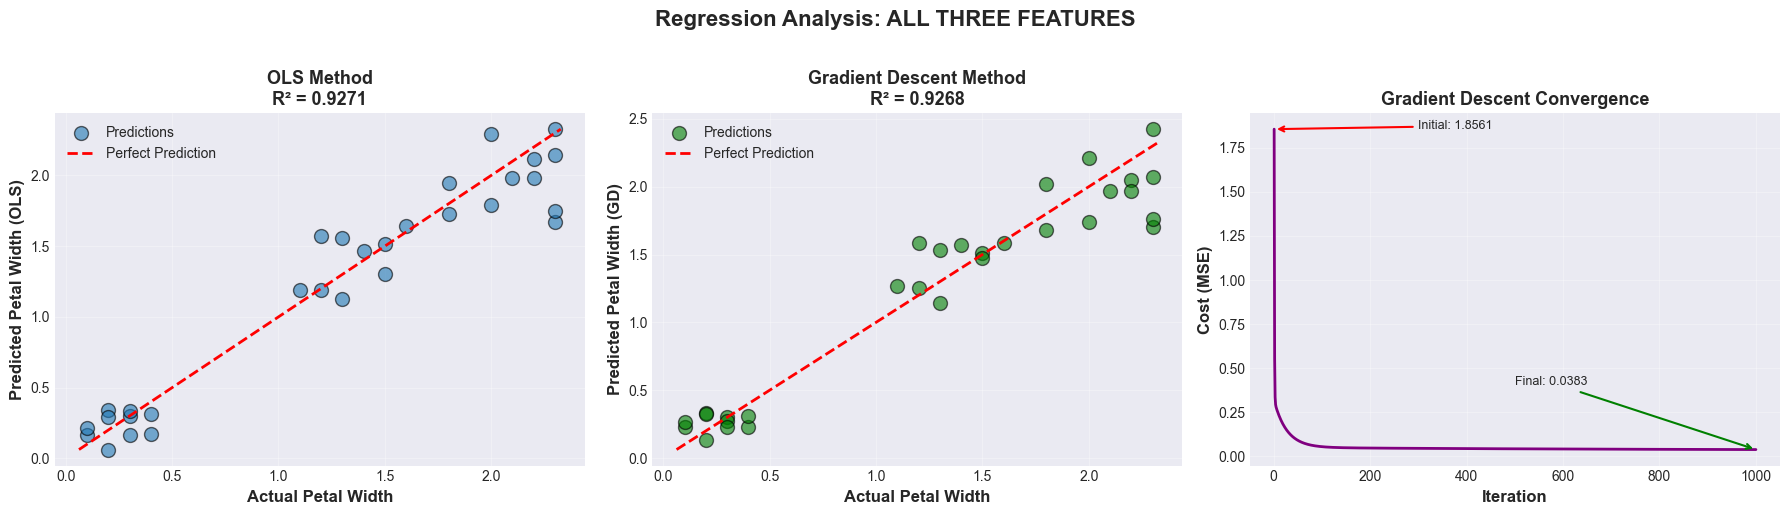

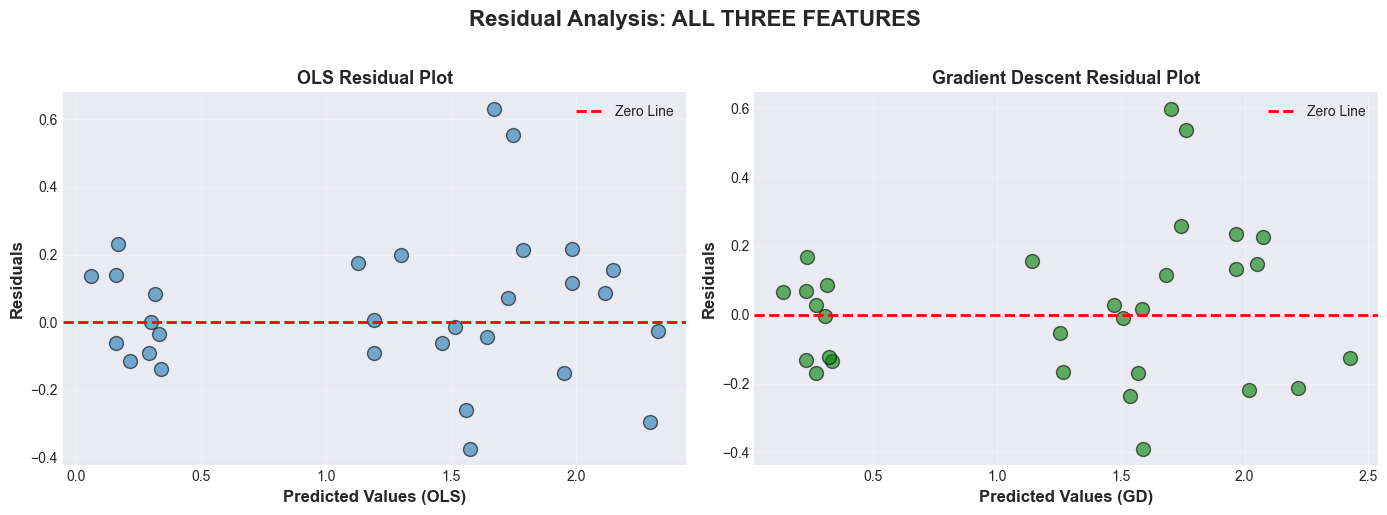

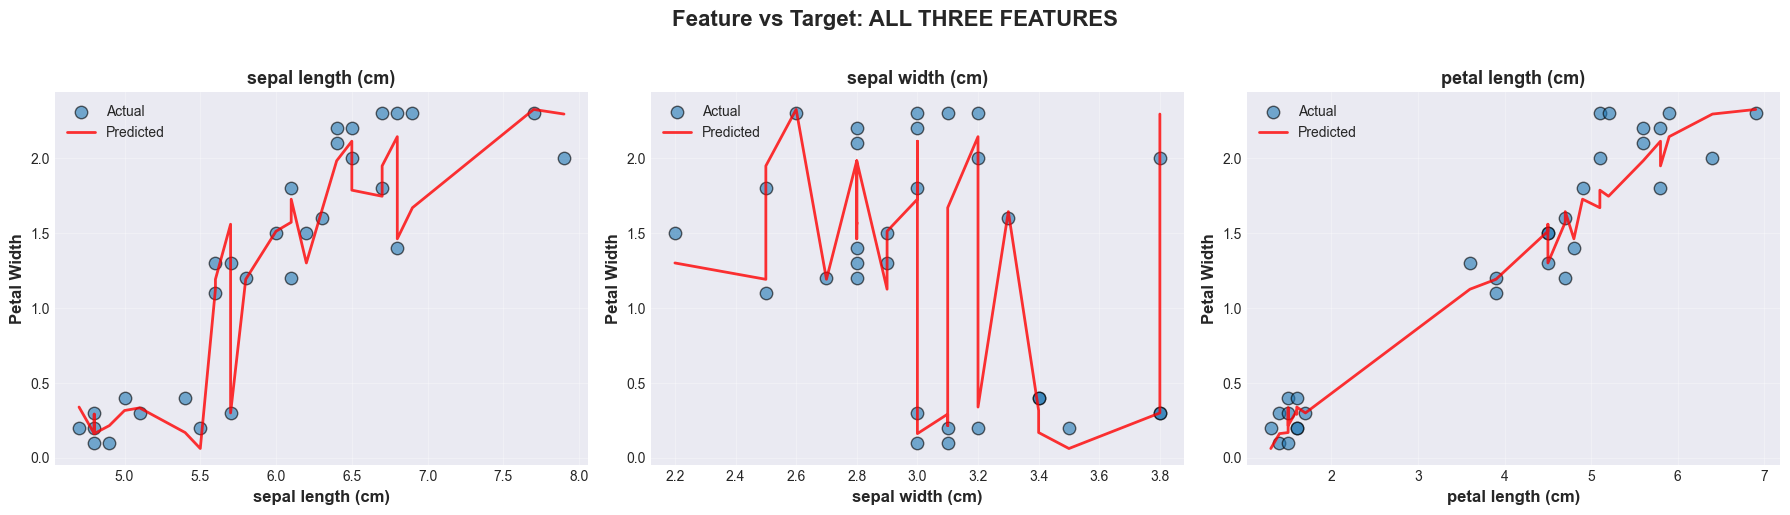

In [14]:
train_and_evaluate(X, y, 3, "ALL THREE FEATURES", feature_names)

### Experiment 2: First Two Features Only

REGRESSION WITH FIRST TWO FEATURES
Features used: sepal length (cm), sepal width (cm)

Training set size: 120
Testing set size: 30
Feature matrix shape (with bias): (120, 3)

--------------------------------------------------------------------------------
METHOD 1: ORDINARY LEAST SQUARES (OLS)
--------------------------------------------------------------------------------
Learned Parameters (θ):
  Bias (θ₀): -1.433255
  sepal length (cm) (θ₍1₎): 0.703869
  sepal width (cm) (θ₍2₎): -0.480884

Performance Metrics:
  R² Score: 0.805427
  Adjusted R² Score: 0.791014
  Mean Squared Error: 0.123681

--------------------------------------------------------------------------------
METHOD 2: BATCH GRADIENT DESCENT
--------------------------------------------------------------------------------
Hyperparameters:
  Learning rate (α): 0.01
  Max iterations: 1000
  Convergence tolerance: 1e-6


Learned Parameters (θ):
  Bias (θ₀): -0.186632
  sepal length (cm) (θ₍1₎): 0.581494
  sepal width (cm) (θ

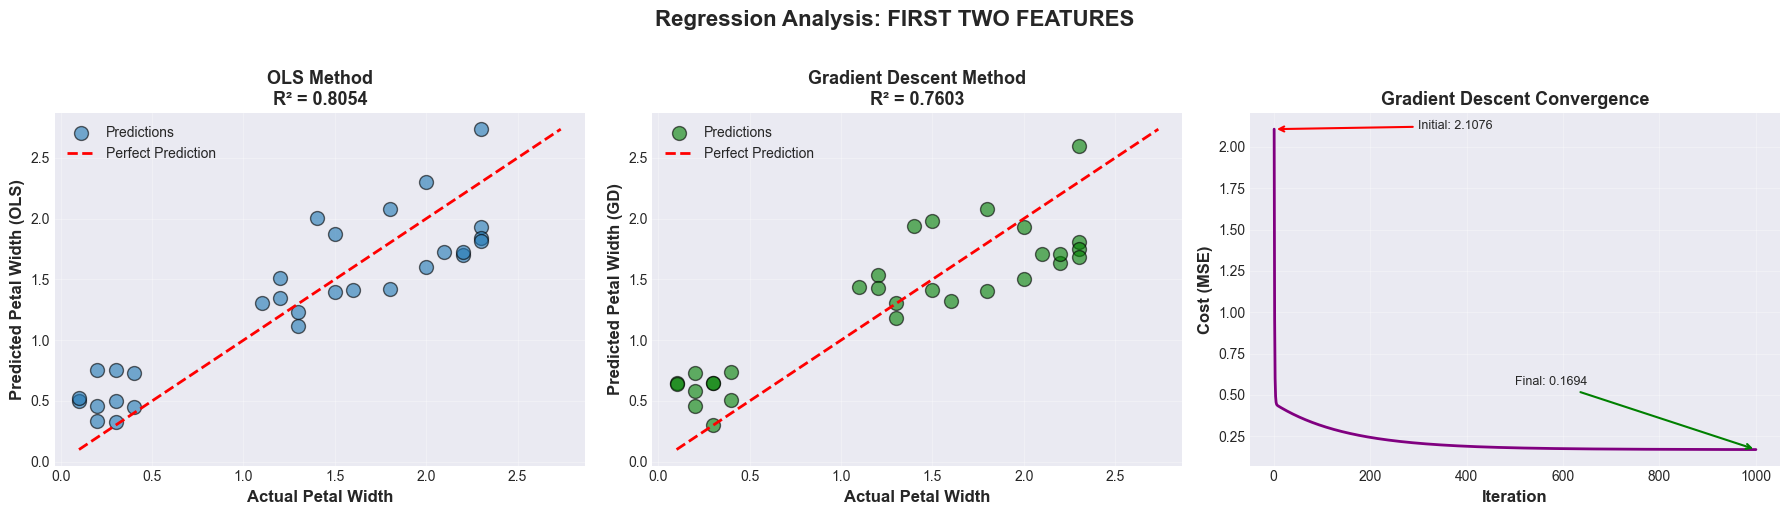

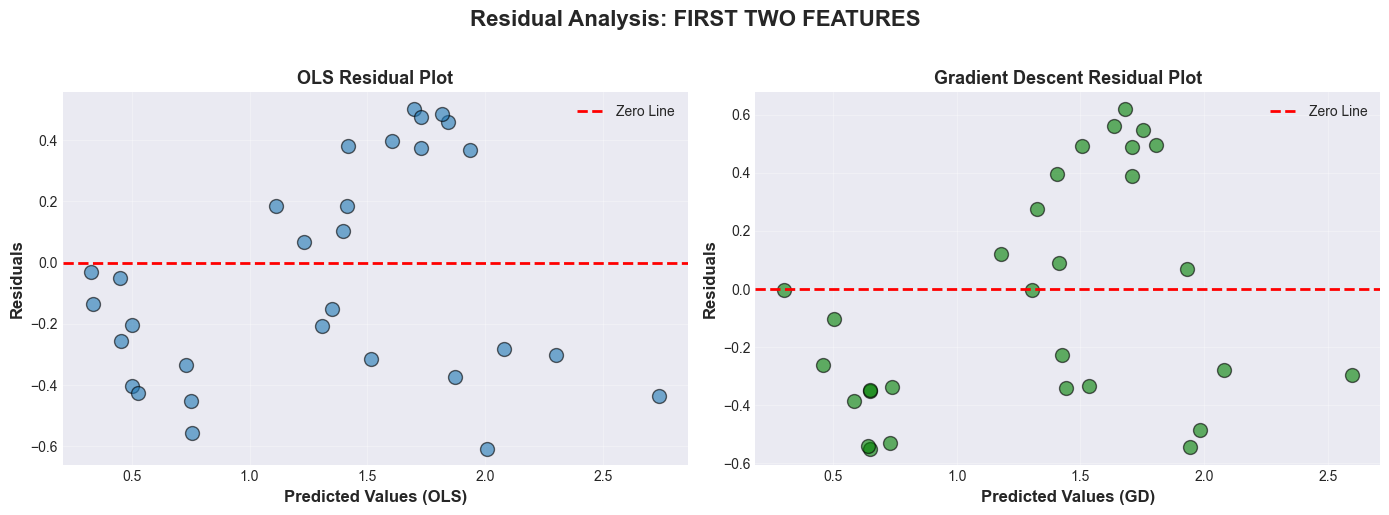

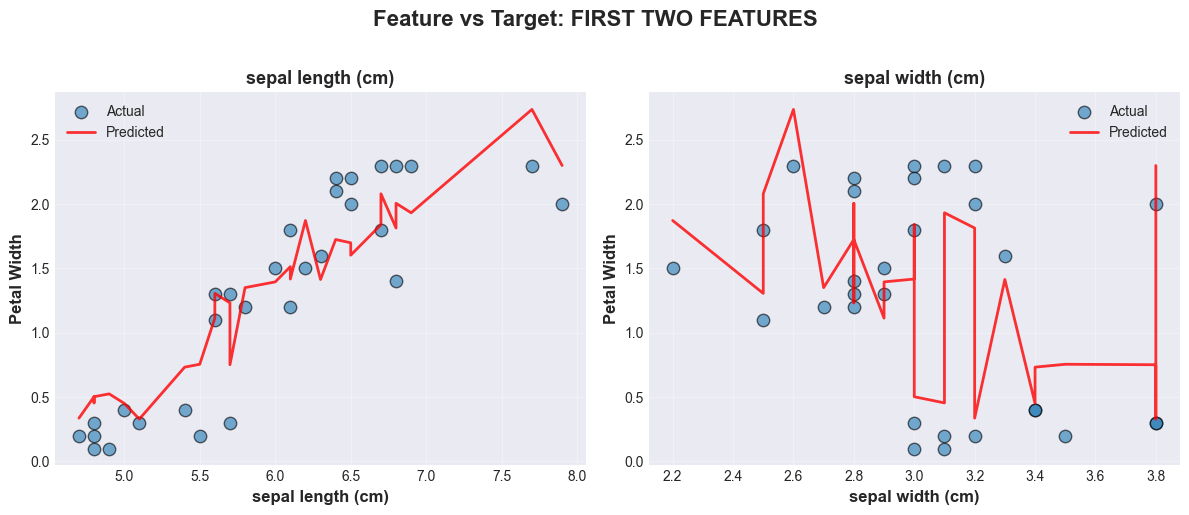

In [15]:
train_and_evaluate(X, y, 2, "FIRST TWO FEATURES", feature_names)

### Experiment 3: First Feature Only

REGRESSION WITH FIRST FEATURE ONLY
Features used: sepal length (cm)

Training set size: 120
Testing set size: 30
Feature matrix shape (with bias): (120, 2)

--------------------------------------------------------------------------------
METHOD 1: ORDINARY LEAST SQUARES (OLS)
--------------------------------------------------------------------------------
Learned Parameters (θ):
  Bias (θ₀): -3.068407
  sepal length (cm) (θ₍1₎): 0.731902

Performance Metrics:
  R² Score: 0.757501
  Adjusted R² Score: 0.748840
  Mean Squared Error: 0.154146

--------------------------------------------------------------------------------
METHOD 2: BATCH GRADIENT DESCENT
--------------------------------------------------------------------------------
Hyperparameters:
  Learning rate (α): 0.05
  Max iterations: 1000
  Convergence tolerance: 1e-6


Learned Parameters (θ):
  Bias (θ₀): -1.872520
  sepal length (cm) (θ₍1₎): 0.529953

Performance Metrics:
  R² Score: 0.665276
  Adjusted R² Score: 0.653322
  M

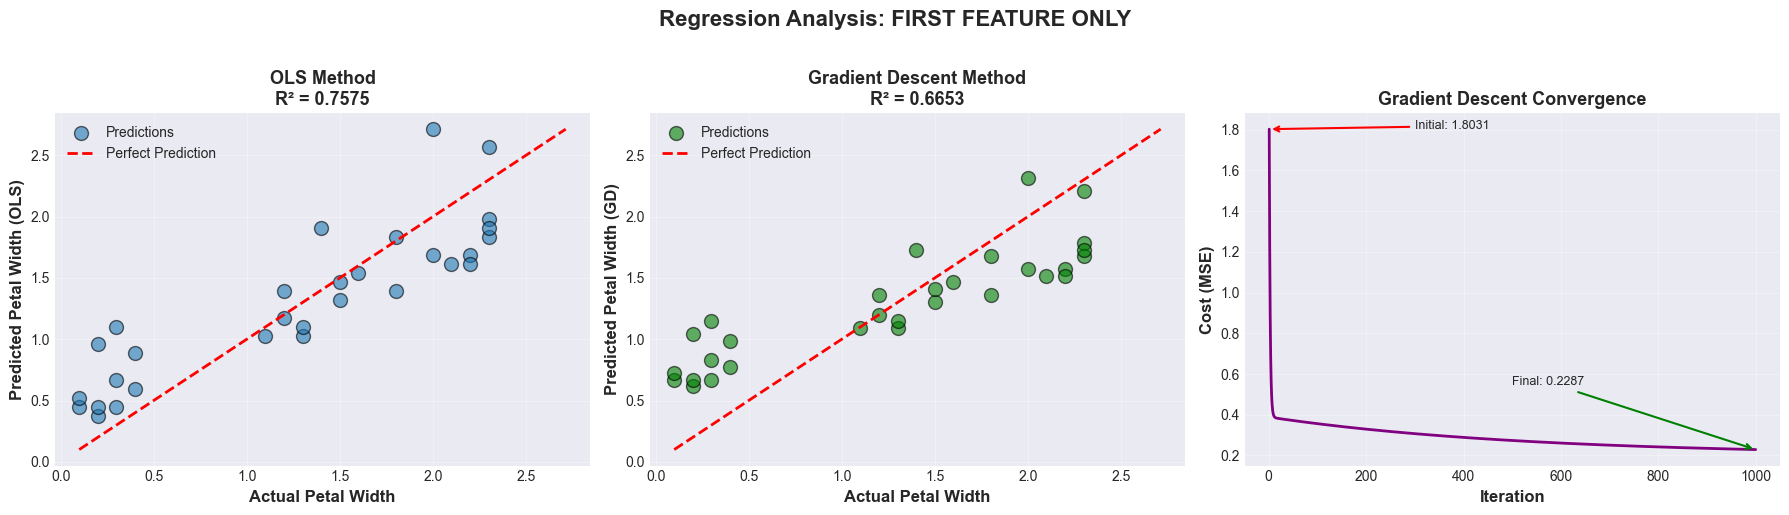

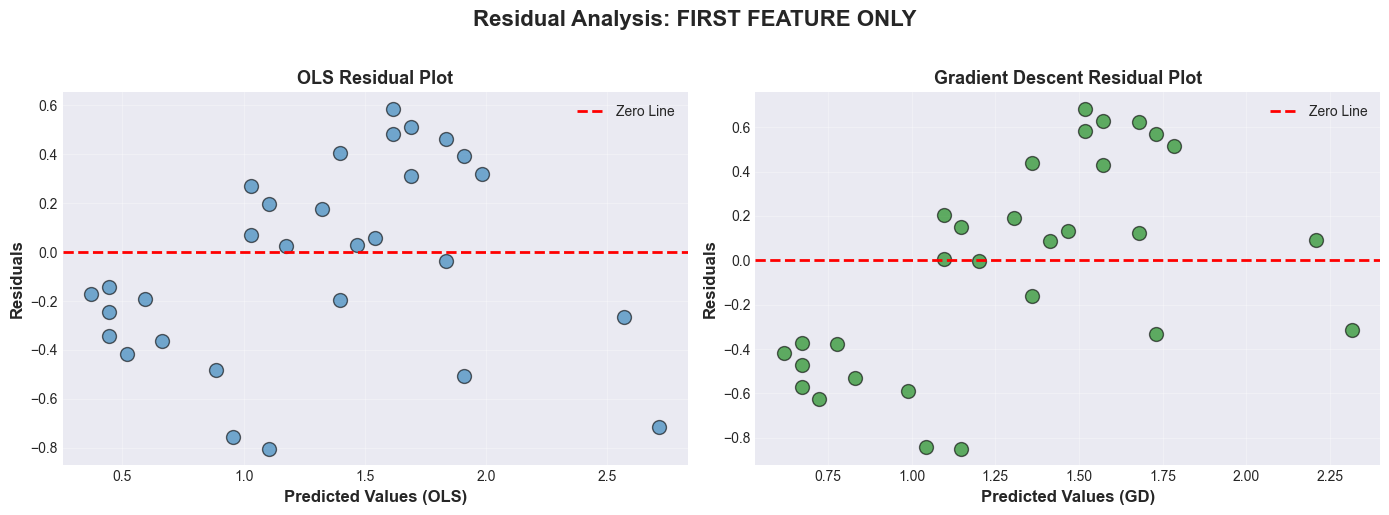

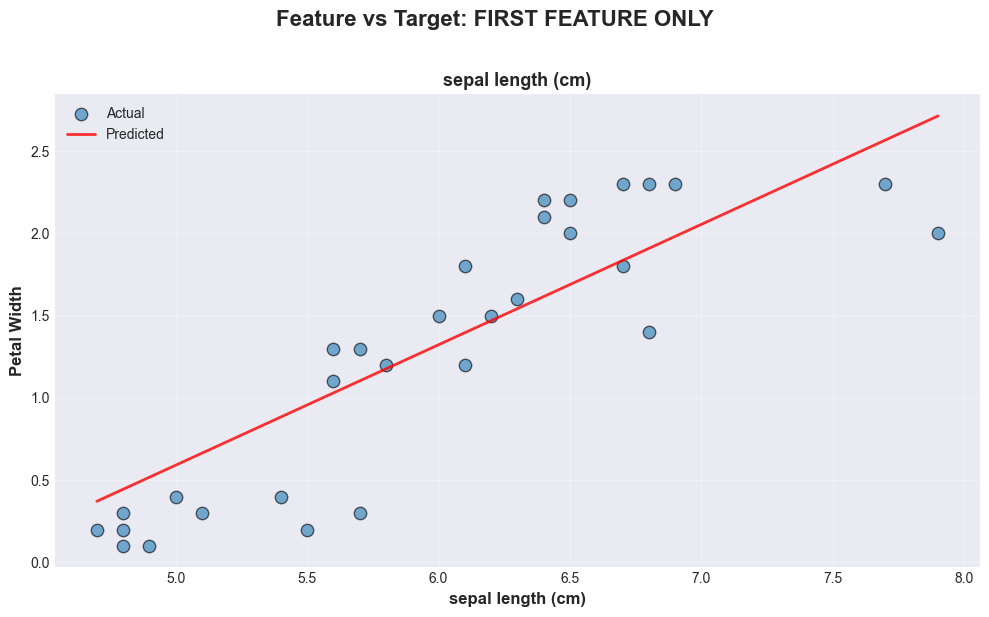

In [16]:
train_and_evaluate(X, y, 1, "FIRST FEATURE ONLY", feature_names)

## Section 8: Summary Comparison Across All Experiments

GENERATING SUMMARY COMPARISON PLOT



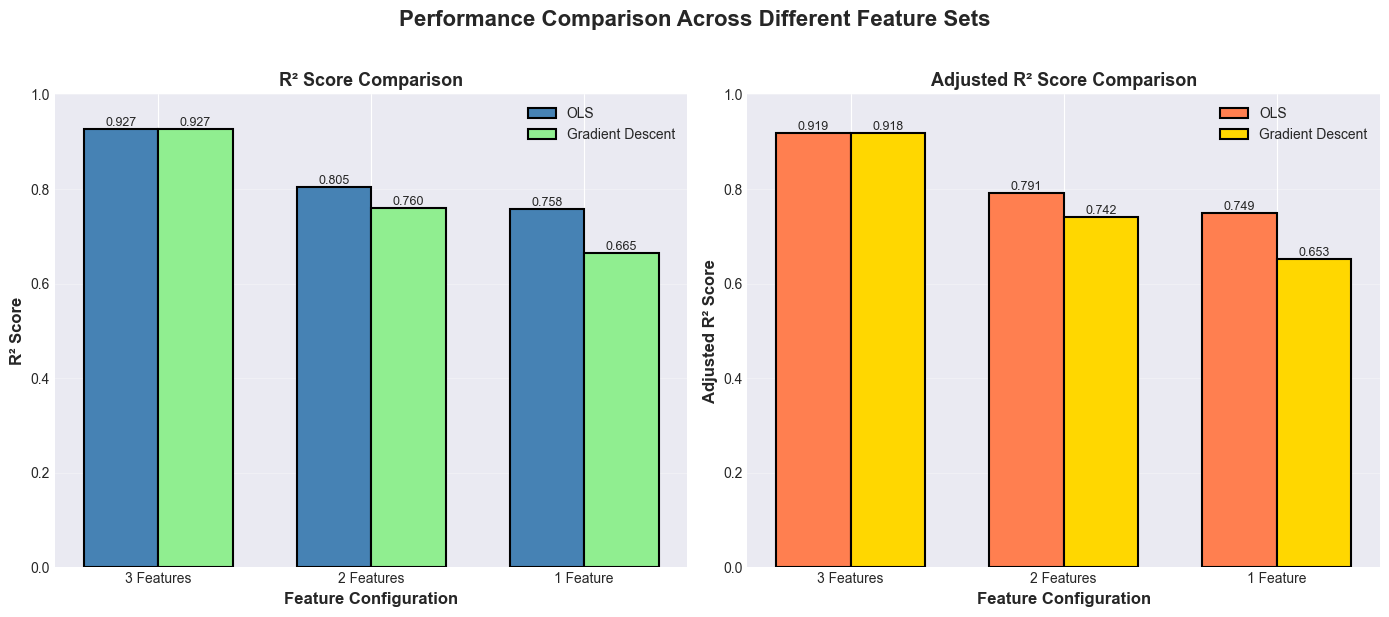

In [17]:
print("="*80)
print("GENERATING SUMMARY COMPARISON PLOT")
print("="*80)
print()

# Re-run quick evaluation to get all metrics for comparison
results = []
for n_feat, desc in [(3, "3 Features"), (2, "2 Features"), (1, "1 Feature")]:
    X_train, X_test, y_train, y_test = train_test_split(
        X[:, :n_feat], y, test_size=0.2, random_state=42
    )
    X_train_bias = np.c_[np.ones(X_train.shape[0]), X_train]
    X_test_bias = np.c_[np.ones(X_test.shape[0]), X_test]

    # OLS
    theta_ols = ols_regression(X_train_bias, y_train)
    y_pred_ols = np.dot(X_test_bias, theta_ols)
    r2_ols = calculate_r2_score(y_test, y_pred_ols)
    adj_r2_ols = calculate_adjusted_r2(y_test, y_pred_ols, n_feat)

    # GD
    theta_gd, _ = batch_gradient_descent(X_train_bias, y_train,
                                         learning_rate=0.01 if n_feat > 1 else 0.05)
    y_pred_gd = np.dot(X_test_bias, theta_gd)
    r2_gd = calculate_r2_score(y_test, y_pred_gd)
    adj_r2_gd = calculate_adjusted_r2(y_test, y_pred_gd, n_feat)

    results.append({
        'features': desc,
        'r2_ols': r2_ols,
        'adj_r2_ols': adj_r2_ols,
        'r2_gd': r2_gd,
        'adj_r2_gd': adj_r2_gd
    })

# Create comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Performance Comparison Across Different Feature Sets',
             fontsize=16, fontweight='bold', y=1.02)

feature_labels = [r['features'] for r in results]
x_pos = np.arange(len(feature_labels))
width = 0.35

# Plot R² scores
ax1 = axes[0]
r2_ols_values = [r['r2_ols'] for r in results]
r2_gd_values = [r['r2_gd'] for r in results]

bars1 = ax1.bar(x_pos - width/2, r2_ols_values, width,
                label='OLS', color='steelblue', edgecolor='black', linewidth=1.5)
bars2 = ax1.bar(x_pos + width/2, r2_gd_values, width,
                label='Gradient Descent', color='lightgreen', edgecolor='black', linewidth=1.5)

ax1.set_xlabel('Feature Configuration', fontsize=12, fontweight='bold')
ax1.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax1.set_title('R² Score Comparison', fontsize=13, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(feature_labels)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim([0, 1])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Plot Adjusted R² scores
ax2 = axes[1]
adj_r2_ols_values = [r['adj_r2_ols'] for r in results]
adj_r2_gd_values = [r['adj_r2_gd'] for r in results]

bars3 = ax2.bar(x_pos - width/2, adj_r2_ols_values, width,
                label='OLS', color='coral', edgecolor='black', linewidth=1.5)
bars4 = ax2.bar(x_pos + width/2, adj_r2_gd_values, width,
                label='Gradient Descent', color='gold', edgecolor='black', linewidth=1.5)

ax2.set_xlabel('Feature Configuration', fontsize=12, fontweight='bold')
ax2.set_ylabel('Adjusted R² Score', fontsize=12, fontweight='bold')
ax2.set_title('Adjusted R² Score Comparison', fontsize=13, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(feature_labels)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim([0, 1])

# Add value labels on bars
for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
print()

## Final Summary and Conclusions

In [18]:
print("="*80)
print("SUMMARY AND CONCLUSIONS")
print("="*80)
print()
print("Key Findings:")
print("  1. Using more relevant features generally improves prediction accuracy")
print("  2. Adjusted R² accounts for the number of features used")
print("  3. OLS provides the exact mathematical solution")
print("  4. Gradient Descent converges to approximately the same solution")
print()
print("Implementation Details:")
print("  • Bias term added manually to feature matrix")
print("  • OLS: Closed-form solution using matrix operations")
print("  • Gradient Descent: Iterative optimization with learning rate tuning")
print("  • 80-20 train-test split for evaluation")
print()
print("="*80)
print("PROGRAM COMPLETED SUCCESSFULLY")
print("="*80)
print()

SUMMARY AND CONCLUSIONS

Key Findings:
  1. Using more relevant features generally improves prediction accuracy
  2. Adjusted R² accounts for the number of features used
  3. OLS provides the exact mathematical solution
  4. Gradient Descent converges to approximately the same solution

Implementation Details:
  • Bias term added manually to feature matrix
  • OLS: Closed-form solution using matrix operations
  • Gradient Descent: Iterative optimization with learning rate tuning
  • 80-20 train-test split for evaluation

PROGRAM COMPLETED SUCCESSFULLY

